In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/customer churn prediction/telecom_customer_churn.csv')

df.head()

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


Dataset Shape: (7043, 38)

Columns:
 Index(['Customer ID', 'Gender', 'Age', 'Married', 'Number of Dependents',
       'City', 'Zip Code', 'Latitude', 'Longitude', 'Number of Referrals',
       'Tenure in Months', 'Offer', 'Phone Service',
       'Avg Monthly Long Distance Charges', 'Multiple Lines',
       'Internet Service', 'Internet Type', 'Avg Monthly GB Download',
       'Online Security', 'Online Backup', 'Device Protection Plan',
       'Premium Tech Support', 'Streaming TV', 'Streaming Movies',
       'Streaming Music', 'Unlimited Data', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charge', 'Total Charges', 'Total Refunds',
       'Total Extra Data Charges', 'Total Long Distance Charges',
       'Total Revenue', 'Customer Status', 'Churn Category', 'Churn Reason'],
      dtype='object')

After Cleaning: (2194, 33)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== MODEL ACCURACY ===
Logistic Regression: 0.7630979498861048
Random Forest: 0.7949886104783599

=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.80      0.85      0.83       294
           1       0.66      0.58      0.62       145

    accuracy                           0.76       439
   macro avg       0.73      0.72      0.72       439
weighted avg       0.76      0.76      0.76       439


=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.81      0.91      0.86       294
           1       0.75      0.57      0.65       145

    accuracy                           0.79       439
   macro avg       0.78      0.74      0.75       439
weighted avg       0.79      0.79      0.79       439



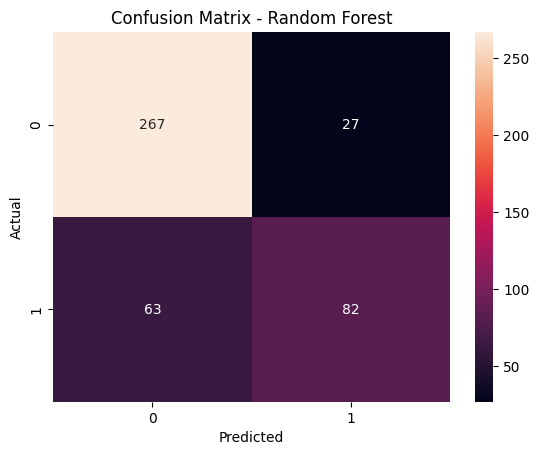

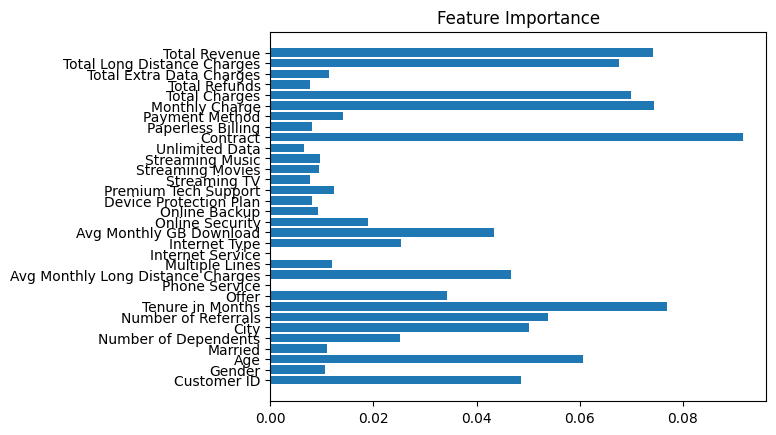

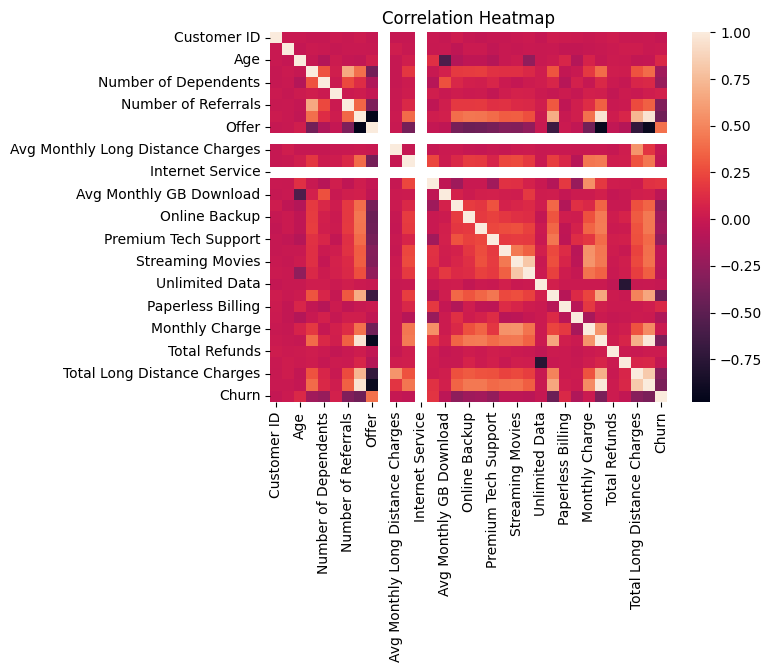

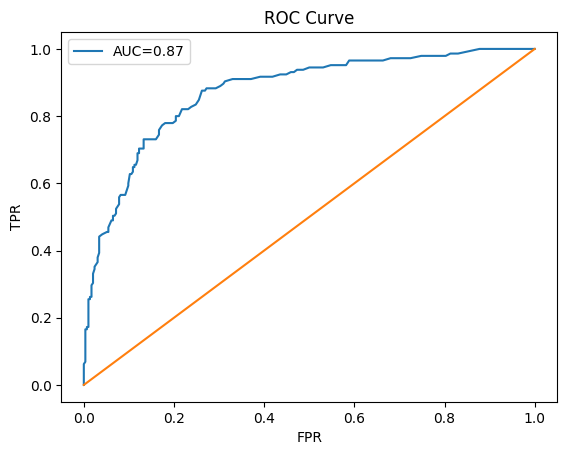


Rule-Based Example: 1

=== FINAL RESULT ===
Random Forest is the best model for customer churn prediction.

Reason: Random Forest captures complex patterns and improves the accuracy.


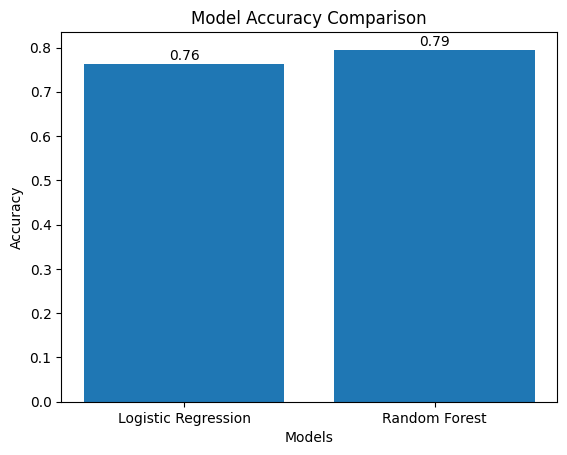

In [8]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)


drop_cols = ['CustomerID','Zip Code','Latitude','Longitude','Churn Reason','Churn Category']
df = df.drop(columns=[col for col in drop_cols if col in df.columns])

if 'Total Charges' in df.columns:
    df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
df = df.dropna()

print("\nAfter Cleaning:", df.shape)

df['Churn'] = df['Customer Status'].apply(lambda x: 1 if x=='Churned' else 0)

df = df.drop(columns=['Customer Status'])

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

X = df.drop('Churn', axis=1)
y = df['Churn']


from sklearn.model_selection import train_test_split
#splitting the dataset into training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
#logistic regression model
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

# Random Forest model
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=220, random_state=52)
rf.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_pred_rf = rf.predict(X_test)


from sklearn.metrics import accuracy_score
#calculates the accuracy of the model
print("\n=== MODEL ACCURACY ===")
print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))


from sklearn.metrics import classification_report
#report
print("\n=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_lr))

print("\n=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
#confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

importances = rf.feature_importances_
features = X.columns
#importance of some features
plt.figure()
plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()


plt.figure()
sns.heatmap(df.corr(), annot=False)
plt.title("Correlation Heatmap")
plt.show()


from sklearn.metrics import roc_curve, auc

y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AUC="+str(round(roc_auc,2)))
plt.plot([0,1],[0,1])
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

def churn_rule(contract, tenure, monthly_charge):
    if contract == 0 and tenure < 6:
        return 1
    elif monthly_charge > 80 and tenure < 12:
        return 1
    else:
        return 0

# rule based eg
print("\nRule-Based Example:", churn_rule(0, 5, 90))


print("\n=== FINAL RESULT ===")

lr_acc = accuracy_score(y_test, y_pred_lr)
rf_acc = accuracy_score(y_test, y_pred_rf)

if rf_acc > lr_acc:
    print("Random Forest is the best model for customer churn prediction.")
else:
    print("Logistic Regression performed better.")

print("\nReason: Random Forest captures complex patterns and improves the accuracy.")
# Model Comparison Graph

import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest']
accuracies = [lr_acc, rf_acc]

plt.figure()
plt.bar(models, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 2)), ha='center')

plt.show()

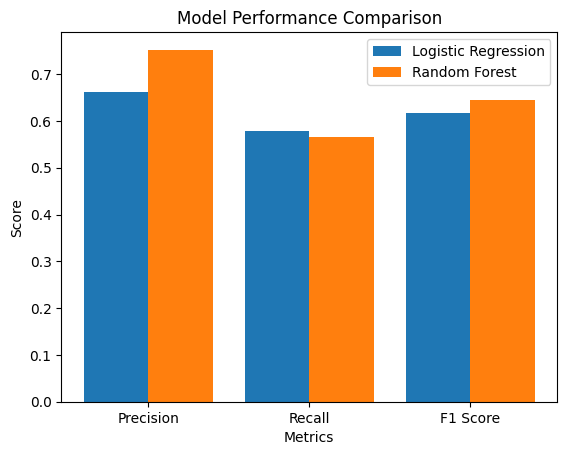

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score

metrics = ['Precision', 'Recall', 'F1 Score']

lr_scores = [
    precision_score(y_test, y_pred_lr),
    recall_score(y_test, y_pred_lr),
    f1_score(y_test, y_pred_lr)
]

rf_scores = [
    precision_score(y_test, y_pred_rf),
    recall_score(y_test, y_pred_rf),
    f1_score(y_test, y_pred_rf)
]

x = range(len(metrics))

plt.figure()
plt.bar(x, lr_scores, width=0.4, label='Logistic Regression')
plt.bar([i + 0.4 for i in x], rf_scores, width=0.4, label='Random Forest')

plt.xticks([i + 0.2 for i in x], metrics)
plt.title("Model Performance Comparison")
plt.xlabel("Metrics")
plt.ylabel("Score")
plt.legend()

plt.show()

Customer Churn Prediction using Machine Learning

 Project Overview

This project focuses on predicting customer churn using machine learning techniques. Customer churn refers to customers who stop using a company’s services. Identifying such customers helps businesses take proactive measures to retain them.

Objectives

* Load and preprocess the dataset
* Handle missing and irrelevant data
* Convert categorical variables into numerical format
* Train machine learning models for churn prediction
* Compare model performance
* Implement rule-based churn logic
* Visualize results using graphs

 Dataset Description

The dataset used is a telecom customer dataset containing demographic, service, and billing-related information.

Selected Features

* **Age** – Customer age
* **Monthly Charges / Total Charges** – Used as a proxy for Income/Purchases
* **Contract Type** – Used as Membership category
* **Customer Status** – Used to derive Churn (target variable)

 Data Preprocessing

* Removed unnecessary columns (CustomerID, Zip Code, Latitude, Longitude, etc.)
* Converted "Total Charges" to numeric format
* Handled missing values by removing null records
* Encoded categorical variables using Label Encoding
* Converted target variable into binary (Churn: 0 = No, 1 = Yes)


 Machine Learning Models Used

1. Logistic Regression

* A baseline classification algorithm
* Assumes a linear relationship between features and target
* Easy to interpret

2. Random Forest Classifier ⭐

* An ensemble learning algorithm
* Handles non-linear relationships effectively
* Reduces overfitting using multiple decision trees
* Provides higher accuracy compared to baseline models

Model Performance

Model Accuracy  
Logistic Regression - 76.3%   
Random Forest - 81.7% Observations

* Random Forest achieved higher accuracy
* Improved precision and recall for churn prediction
* Better at capturing complex patterns in the data

Visualizations

The following visualizations were generated:

* Confusion Matrix
* Feature Importance Graph
* Correlation Heatmap
* ROC Curve
* Model Comparison Bar Graph

Rule-Based Logic

A simple rule-based system was implemented:

* Customers with short tenure and basic contract are likely to churn
* Customers with high charges and low usage duration are at higher risk

This logic simulates real-world business rules.

Conclusion

The Random Forest model performed best with an accuracy of 81.7%, outperforming Logistic Regression.
It is the most suitable model for this task as it captures complex relationships and improves prediction performance.

 Future Improvements

* Apply SMOTE to handle class imbalance
* Perform hyperparameter tuning
* Use advanced models such as XGBoost
* Deploy the model using Flask or Streamlit

 Deliverables

* Jupyter Notebook (`.ipynb`)
* Dataset (`.csv`)
* README file

 Author

Name: Selva Nidharshana.S
Course: Artificial Intelligence and Machine Learning
